# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [1]:
ПІБ = 'Андрусишин Соломія Володимирівна'        # напр. 'Шевченко Тарас'
ГРУПА = 'Ші-31'      # напр. 'КН-31'
ВАРІАНТ = 1     # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [2]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(1)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Андрусишин Соломія Володимирівна, Ші-31, варіант 1
ваш потік:                   P>50
ваша пара для графіка 3:     швидкість вітру та потік P>10
ваш агрегат для етапу 4:     медіана
ваше додаткове питання:      Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [196]:
df = pd.read_excel(ФАЙЛ)

print(df.head())
print(df.dtypes)

   Unnamed: 0        ftp://ftp.swpc.noaa.gov/pub/lists/particle/ Unnamed: 2 Unnamed: 3 Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7 Unnamed: 8 Unnamed: 9 Unnamed: 10 Unnamed: 11 Unnamed: 12  \
0         NaN                                                NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN         NaN         NaN         NaN   
1         NaN                :Data_list: 20170901_Gs_part_5m.txt        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN         NaN         NaN         NaN   
2         NaN                     :Created: 2017 Sep 02 0011 UTC        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN         NaN         NaN         NaN   
3         NaN  # Prepared by the U.S. Dept. of Commerce, NOAA...        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN         NaN         NaN         NaN   
4         NaN  # Please send comments an

**Відповідь 1.1:** *(чому звичайне читання дало саме такий результат)* Зіичайне читання дало такий результат,оскільки воно (Pandas) за замовчуванням сприйняло перші радяки аркуша за назви стовпців, тип даних вийшов object оскільки на аркуші знаходять різні типи даих 

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [12]:
RAW = pd.read_excel(ФАЙЛ, header=None)
print(RAW.shape)
print(RAW.head(30))

(7226, 32)
    0                                                  1    2    3     4         5        6      7      8      9       10      11      12     13     14  15  \
0  NaN        ftp://ftp.swpc.noaa.gov/pub/lists/particle/  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
1  NaN                                                NaN  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
2  NaN                :Data_list: 20170901_Gs_part_5m.txt  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
3  NaN                     :Created: 2017 Sep 02 0011 UTC  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
4  NaN  # Prepared by the U.S. Dept. of Commerce, NOAA...  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
5  NaN  # Please send comments and 

### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [ ]:
RAW.notna().sum()

0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64

**Відповідь 1.3:** *(скільки таблиць і які стовпці кожна займає)* З цього можна визначити і зрозуміти де у нас є таблиці.Наприклд по даним з 1 - 14 стовпець можна зрозуміти що це наша перша таблиця. Потім йде й стовпецб проміжку і далі з 16-19 стовпець йде друга таблиця. І як можна зрозуміти з 28 по 31 стовпець йде наша остання таблиця ,тобто третя.

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [199]:
#print(RAW.iloc[0:25, 1:15].to_string())

#print(RAW.iloc[0:25, 16:20].to_string())

print(RAW.iloc[0:25, 24:31].to_string())


    24  25                                                                               26   27   28   29   30
0  NaN NaN                                                     http://umtof.umd.edu/pm/crn/  NaN  NaN  NaN  NaN
1  NaN NaN                                                                              NaN  NaN  NaN  NaN  NaN
2  NaN NaN                                                       SOHO CELIAS Proton Monitor  NaN  NaN  NaN  NaN
3  NaN NaN                    Solar Wind Parameters for Carrington Rotation (hour averages)  NaN  NaN  NaN  NaN
4  NaN NaN                                                            Proton speed [km/sec]  NaN  NaN  NaN  NaN
5  NaN NaN                                    Proton density [protons per cubic centimeter]  NaN  NaN  NaN  NaN
6  NaN NaN                                                                              NaN  NaN  NaN  NaN  NaN
7  NaN NaN  Measurement time (Year, Month, Day of Month, Day of Year, Hour, Minute, Second)  NaN  NaN  N

**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
| A | GOES-15 | Particles: Protons/cm²-s-sr; Electrons: Electrons/cm²-s-sr |
| B | NOAA | для Radio Flux 10.7 |
| C | SOHO CELIAS Proton Monitor | Proton speed: km/sec; Proton density: protons/cm³ |


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [46]:
# ВАШ КОД
A = RAW.iloc[26:, 1:15].copy()

A.columns = [
    'Year', 'Month', 'Day', 'Time', 'JulianDay', 'Seconds',
    'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100',
    'E>0.8', 'E>2.0'
]

A = A.apply(pd.to_numeric, errors='coerce')


B = RAW.iloc[27:52, 16:20].copy()

B.columns = [
    'Year', 'Month', 'Day', 'RadioFlux10.7'
]

B = B.apply(pd.to_numeric, errors='coerce')


C = RAW.iloc[27:628, 26:32].copy()

C.columns = [
    'Year', 'Month', 'Day', 'Hour', 'Speed', 'Density'
]

C = C.apply(pd.to_numeric, errors='coerce')


print(A.head())
print(B.head())
print(C.head())



    Year  Month  Day  Time  JulianDay  Seconds    P>1    P>5   P>10    P>30    P>50   P>100    E>0.8   E>2.0
26  2017      8   28     0      57993        0  12.00  0.260  0.180  0.1140  0.1040  0.0793  23600.0  1180.0
27  2017      8   28     5      57993      300  19.40  0.690  0.314  0.1120  0.0612  0.0251  23100.0  1160.0
28  2017      8   28    10      57993      600   8.48  0.168  0.130  0.0717  0.0614  0.0304  22200.0  1090.0
29  2017      8   28    15      57993      900  15.40  0.566  0.198  0.0926  0.0568  0.0251  20400.0   997.0
30  2017      8   28    20      57993     1200   6.41  0.156  0.118  0.0597  0.0494  0.0251  18500.0   875.0
    Year  Month  Day  RadioFlux10.7
27  2017      8   28             82
28  2017      8   29             84
29  2017      8   30             87
30  2017      8   31             92
31  2017      9    1             93
    Year  Month  Day  Hour  Speed  Density
27    17      8   28     0    285      3.0
28    17      8   28     1    305      3.4
2

### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [48]:
A['ts'] = pd.to_datetime(A[['Year', 'Month', 'Day']]) + pd.to_timedelta(A['Seconds'], unit='s')

B['ts'] = pd.to_datetime(B[['Year', 'Month', 'Day']])

C['Year'] = C['Year'] + 2000
C['ts'] = pd.to_datetime(C[['Year', 'Month', 'Day']]) + pd.to_timedelta(C['Hour'], unit='h')

print(A.head())
print(B.head())
print(C.head())

print("A:", A['ts'].min(), A['ts'].max())
print("B:", B['ts'].min(), B['ts'].max())
print("C:", C['ts'].min(), C['ts'].max())

    Year  Month  Day  Time  JulianDay  Seconds    P>1    P>5   P>10    P>30    P>50   P>100    E>0.8   E>2.0                  ts
26  2017      8   28     0      57993        0  12.00  0.260  0.180  0.1140  0.1040  0.0793  23600.0  1180.0 2017-08-28 00:00:00
27  2017      8   28     5      57993      300  19.40  0.690  0.314  0.1120  0.0612  0.0251  23100.0  1160.0 2017-08-28 00:05:00
28  2017      8   28    10      57993      600   8.48  0.168  0.130  0.0717  0.0614  0.0304  22200.0  1090.0 2017-08-28 00:10:00
29  2017      8   28    15      57993      900  15.40  0.566  0.198  0.0926  0.0568  0.0251  20400.0   997.0 2017-08-28 00:15:00
30  2017      8   28    20      57993     1200   6.41  0.156  0.118  0.0597  0.0494  0.0251  18500.0   875.0 2017-08-28 00:20:00
    Year  Month  Day  RadioFlux10.7         ts
27  2017      8   28             82 2017-08-28
28  2017      8   29             84 2017-08-29
29  2017      8   30             87 2017-08-30
30  2017      8   31             92 20

**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [49]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [203]:
print(A.shape)
print(A.dtypes)
print(A.isna().sum())
print(A.duplicated().sum())
print(A.describe())


(7200, 15)
Year                  int64
Month                 int64
Day                   int64
Time                  int64
JulianDay             int64
Seconds               int64
P>1                 float64
P>5                 float64
P>10                float64
P>30                float64
P>50                float64
P>100               float64
E>0.8               float64
E>2.0               float64
ts           datetime64[us]
dtype: object
Year         0
Month        0
Day          0
Time         0
JulianDay    0
Seconds      0
P>1          3
P>5          3
P>10         3
P>30         3
P>50         3
P>100        3
E>0.8        3
E>2.0        3
ts           0
dtype: int64
0
         Year        Month          Day         Time     JulianDay       Seconds           P>1          P>5         P>10         P>30         P>50       P>100          E>0.8          E>2.0  \
count  7200.0  7200.000000  7200.000000  7200.000000   7200.000000   7200.000000   7197.000000  7197.000000  7197.000000  7

In [201]:
print(B.shape)
print(B.dtypes)
print(B.isna().sum())
print(B.duplicated().sum())
print(B.describe())

(25, 5)
Year                      int64
Month                     int64
Day                       int64
RadioFlux10.7             int64
ts               datetime64[us]
dtype: object
Year             0
Month            0
Day              0
RadioFlux10.7    0
ts               0
dtype: int64
0
         Year      Month        Day  RadioFlux10.7                   ts
count    25.0  25.000000  25.000000      25.000000                   25
mean   2017.0   8.840000  13.960000      92.680000  2017-09-09 00:00:00
min    2017.0   8.000000   1.000000      71.000000  2017-08-28 00:00:00
25%    2017.0   9.000000   7.000000      74.000000  2017-09-03 00:00:00
50%    2017.0   9.000000  13.000000      84.000000  2017-09-09 00:00:00
75%    2017.0   9.000000  19.000000     107.000000  2017-09-15 00:00:00
max    2017.0   9.000000  31.000000     140.000000  2017-09-21 00:00:00
std       0.0   0.374166   8.955817      22.206831                  NaN


In [202]:
print(C.shape)
print(C.dtypes)
print(C.isna().sum())
print(C.duplicated().sum())
print(C.describe())

(601, 7)
Year                int64
Month               int64
Day                 int64
Hour                int64
Speed             float64
Density           float64
ts         datetime64[us]
dtype: object
Year       0
Month      0
Day        0
Hour       0
Speed      8
Density    8
ts         0
dtype: int64
0
         Year       Month         Day        Hour       Speed     Density                   ts
count   601.0  601.000000  601.000000  601.000000  593.000000  593.000000                  601
mean   2017.0    8.840266   13.973378   11.480865  513.394604    2.960371  2017-09-09 12:00:00
min    2017.0    8.000000    1.000000    0.000000  277.000000    0.100000  2017-08-28 00:00:00
25%    2017.0    9.000000    7.000000    5.000000  449.000000    1.800000  2017-09-03 06:00:00
50%    2017.0    9.000000   13.000000   11.000000  520.000000    2.500000  2017-09-09 12:00:00
75%    2017.0    9.000000   19.000000   17.000000  585.000000    3.400000  2017-09-15 18:00:00
max    2017.0    9.00000

### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [78]:
#print(C[C['Speed'] < 0]['Speed'])


#print(C[C['Density'] < 0]['Density'])


#print((C['Speed'] < 0).sum())
#print((C['Density'] < 0).sum())


print("Середнє значення і мінімальне до таблиці C (speed):  ", (C['Speed']).mean(), (C['Speed']).min())
print("Середнє значення і мінімальне до таблиці С (density): ", (C["Density"]).mean(), (C["Density"]).min())

C.loc[C['Speed'] < 0, 'Speed'] = np.nan
C.loc[C['Density'] < 0, 'Density'] = np.nan            

print("Середнє значення і мінімальне до таблиці C (speed):  ", (C['Speed']).mean(), (C['Speed']).min())
print("Середнє значення і мінімальне до таблиці С (density): ", (C["Density"]).mean(), (C["Density"]).min())

Середнє значення і мінімальне до таблиці C (speed):   513.3946037099494 277.0
Середнє значення і мінімальне до таблиці С (density):  2.960370994940978 0.1
Середнє значення і мінімальне до таблиці C (speed):   513.3946037099494 277.0
Середнє значення і мінімальне до таблиці С (density):  2.960370994940978 0.1


**Відповідь 3.2:** У двох стовпцях таблиці C (у стовпці - Speed та Density) були мінімальні значення -1 (сумарно 8 штук), через це вони спотворювали серднє значення*

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [79]:
A[['Year', 'Month', 'Day', 'Time', 'JulianDay', 'Seconds']].describe()

,Year,Month,Day,Time,JulianDay,Seconds
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000


**Відповідь 3.3:** *(які це стовпці та чому середнє для них не має сенсу)*
Наприклад у таблиці А є стовпці з роком , місяцем днем і тд. Для них немає сенсу рахувати середніх значень оскільки вони описують час , а не якусь фізичну величину


---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [132]:
# ВАШ КОД
#print(A.head())
A_hour = A.set_index('ts')
flux_cols = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']
A_mean = A_hour[flux_cols].resample('1h').mean()
A_max = A_hour[flux_cols].resample('1h').max()



A_mean.columns = [col + '_mean' for col in A_mean.columns]
A_max.columns = [col + '_max' for col in A_max.columns]
A_hour = A_mean.merge(
    A_max,
    left_index=True,
    right_index=True
)

print(A_hour.head())

                     P>1_mean  P>5_mean  P>10_mean  P>30_mean  P>50_mean  P>100_mean    E>0.8_mean   E>2.0_mean  P>1_max  P>5_max  P>10_max  P>30_max  P>50_max  P>100_max  E>0.8_max  E>2.0_max
ts                                                                                                                                                                                              
2017-08-28 00:00:00  9.778333  0.324917   0.192917   0.098850   0.077583    0.040692  20941.666667  1011.583333    19.40    0.690     0.314    0.2240    0.1780     0.0793    23600.0     1180.0
2017-08-28 01:00:00  7.994167  0.291667   0.156583   0.072583   0.058700    0.029950  18091.666667   713.000000    13.60    0.512     0.259    0.0919    0.0798     0.0471    20600.0      907.0
2017-08-28 02:00:00  6.099167  0.283000   0.177667   0.084450   0.069642    0.035025  14108.333333   380.833333    10.80    0.479     0.321    0.1210    0.1110     0.0595    15000.0      475.0
2017-08-28 03:00:00  4.752500  0.23

### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

ts
2017-08-28 00:00:00    0.1780
2017-08-28 01:00:00    0.0798
2017-08-28 02:00:00    0.1110
2017-08-28 03:00:00    0.1390
2017-08-28 04:00:00    0.1420
Freq: h, Name: P>50, dtype: float64
ts
2017-08-28 00:00:00    0.06130
2017-08-28 01:00:00    0.05315
2017-08-28 02:00:00    0.06275
2017-08-28 03:00:00    0.05795
2017-08-28 04:00:00    0.06155
Freq: h, Name: P>50, dtype: float64


Text(0, 0.5, 'P>50')

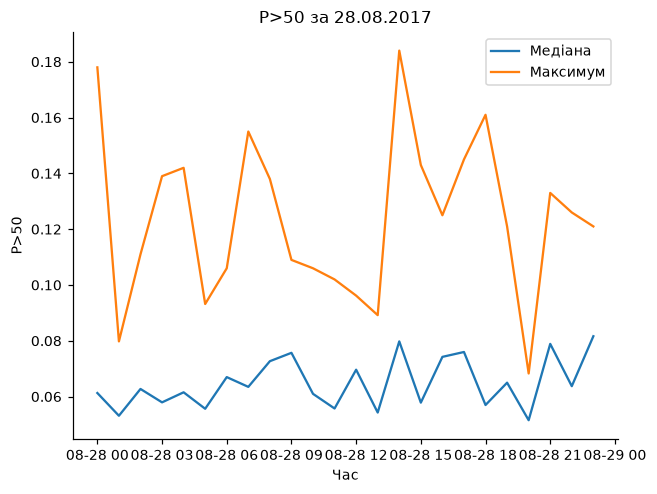

In [205]:
# ВАШ КОД
one_day = A[A['ts'].dt.date == pd.Timestamp('2017-08-28').date()]

one_day = one_day.set_index('ts')
mediana = one_day['P>50'].resample('1h').median()

maxx = one_day['P>50'].resample('1h').max()
print(maxx.head())
print(mediana.head())


plt.plot(mediana.index, mediana, label = 'Медіана')

plt.plot(maxx.index, maxx , label = 'Максимум')

plt.legend()

plt.title('P>50 за 28.08.2017')
plt.xlabel('Час')
plt.ylabel('P>50')

**Відповідь 4.2:** *(чим відрізняються криві та коли це важливо)* Ну по перше ці криві показують різні значення.Крива медіани показує типове значення потоку P>50 протягом кожної години і мало реагує на окремі різкі стрибки. Крива максимуму показує найбільше зафіксоване значення за кожну годину, тому вона значно чутливіша до короткочасних піків. Різниця між кривими стає суттєвою, коли протягом години виникають окремі значення, які значно більші за решту вимірювань.

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [157]:
# ВАШ КОД
M = None
B_hour = B.set_index('ts')
B_hour = B_hour.resample('1h').ffill()

C_hour = C.set_index('ts')
#print(C_hour.head())

#M_inner = A_hour.merge(B_hour, left_index = True, right_index = True, how = 'inner')

#M_inner = M_inner.merge(C_hour, left_index = True, right_index = True, how = 'inner')
#print(M_inner.shape)

M_outer = A_hour.merge(B_hour, left_index = True, right_index = True, how = 'outer')

M_outer = M_outer.merge(C_hour, left_index = True, right_index = True, how = 'outer')
print(M_outer.shape)
M = M_outer
M = M.reset_index()
print(M[M.isna().any(axis=1)])


(601, 26)
                     ts   P>1_mean  P>5_mean  P>10_mean  P>30_mean  P>50_mean  P>100_mean     E>0.8_mean    E>2.0_mean  P>1_max  P>5_max  P>10_max  P>30_max  P>50_max  P>100_max  E>0.8_max  \
175 2017-09-04 07:00:00   6.465833  0.262083   0.171500   0.085483   0.068558    0.031717   90600.000000   7410.833333    10.10    0.593     0.294     0.145    0.1340     0.0523   100000.0   
176 2017-09-04 08:00:00   4.010833  0.256000   0.195833   0.086625   0.070033    0.036492   73483.333333   5048.333333     5.08    0.432     0.336     0.145    0.1340     0.0546    79300.0   
177 2017-09-04 09:00:00   3.268333  0.303417   0.220333   0.105925   0.081975    0.046483   60475.000000   3715.833333     4.42    0.518     0.302     0.162    0.1340     0.0765    68500.0   
178 2017-09-04 10:00:00   3.179167  0.252167   0.181833   0.101900   0.081675    0.054125   64383.333333   4122.500000     4.74    0.372     0.280     0.150    0.1200     0.0894    68400.0   
179 2017-09-04 11:00:00   5.27

**Відповідь 4.3:** *(який тип об'єднання обрано, скільки рядків дає кожен і чому)* Inner - дав мені 577 рядків , в той час коли outer -  дав 601 рядок. Швидше за все я обираю outer, оскільки він залишає всі години які зустрічаються в таблиці, в той час коли inner - лише спільні. А це дає можливість загубити дані ,які не є спільними.Хоча всі таблиці були приведені до погодинного кроку, їхні часові діапазони не повністю збігаються.



### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [158]:
# ВАШ КОД


def group(x):
    if(x < 10):
        return 'тиха'
    elif(x >= 10 and x < 1000):
        return 'активна'
    else:
        return 'дуже активна'

M['група'] = M['P>10_max'].apply(group)    
print(M[['P>10_max', 'група']].head())

   P>10_max група
0     0.314  тиха
1     0.259  тиха
2     0.321  тиха
3     0.244  тиха
4     0.309  тиха


**Самоперевірка етапу 4.**

In [159]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 601 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

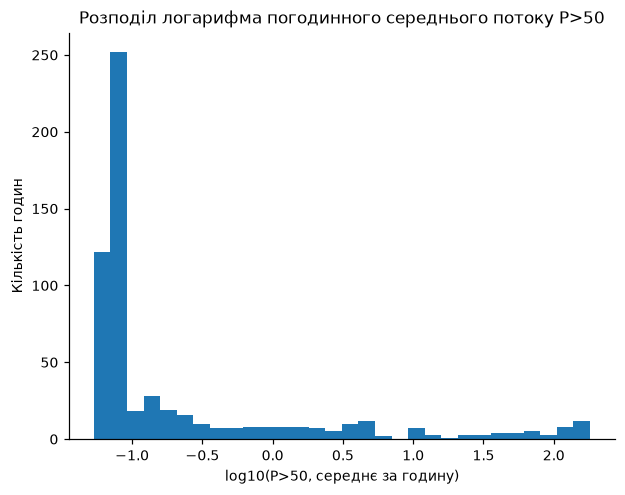

0.08024583333333334
7.44385701010101


In [163]:
# ВАШ КОД

potik = M['P>50_mean']
mediana = potik.median()
average = potik.mean()

#plt.hist(potik, bins=30)
#plt.xlabel('P>50, середнє за годину')
#plt.ylabel('Кількість годин')
#plt.title('Розподіл погодинного середнього потоку P>50')
#plt.show()

potik_log = np.log10(potik[potik > 0])
plt.hist(potik_log, bins=30)
plt.xlabel('log10(P>50, середнє за годину)')
plt.ylabel('Кількість годин')
plt.title('Розподіл логарифма погодинного середнього потоку P>50')
plt.show()

print(mediana)
print(average)

**Висновок:** Більшість годин мають невелике значення потоку,але і є не велика кількість годин із великим значенням.Вони сильно збільшують середнє значення,але через це медіана і така мала,оскільки медіана значно зменшує такі великі значення.Злогарифмувала,окікльки було погано видно і великий діапазон значень стиснувся ,через що тепер краще видно.


### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

0              тиха
1              тиха
2              тиха
3              тиха
4              тиха
           ...     
596            тиха
597            тиха
598            тиха
599            тиха
600    дуже активна
Name: група, Length: 601, dtype: str


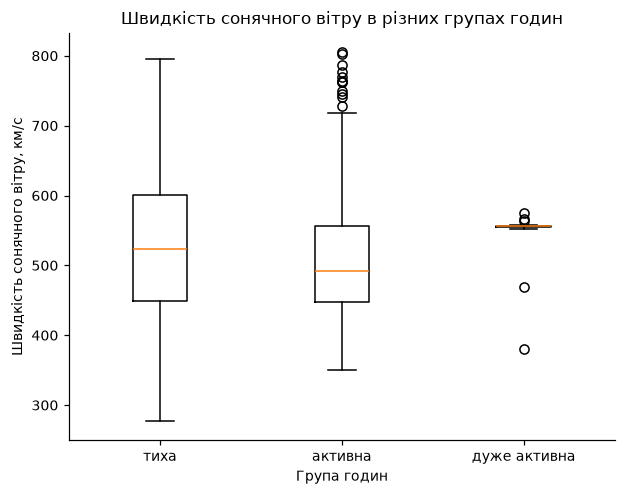

група
тиха            411
активна         171
дуже активна     19
Name: count, dtype: int64
група
активна         171
дуже активна     19
тиха            403
Name: Speed, dtype: int64


In [ ]:
# ВАШ КОД
#P>10 Spped
print(M['група'])
quiet = M[M['група'] == 'тиха']['Speed'].dropna()
active = M[M['група'] == 'активна']['Speed'].dropna()
very_active = M[M['група'] == 'дуже активна']['Speed'].dropna()

plt.boxplot(
    [quiet, active, very_active],
    tick_labels=['тиха', 'активна', 'дуже активна']
)

plt.xlabel('Група годин')
plt.ylabel('Швидкість сонячного вітру, км/с')
plt.title('Швидкість сонячного вітру в різних групах годин')
plt.show()


print(M['група'].value_counts())

print(M.groupby('група')['Speed'].count())

**Висновок:** Отже, побудувавшкт другий графік можна побачити ,що група "тиха" має десь значення 520км/c, група "активна" має менше ,тобто десь на рівні з 500km/c, а дуже активна найбільше -  орієнтовно 550km/c. Графік будувала два рази ,оскільки через не прибранні значення - "Nan' графік показував недокінця чіткі значення.

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

   P>10_mean  Speed
0   0.192917  285.0
1   0.156583  305.0
2   0.177667  309.0
3   0.166333  304.0
4   0.208333  302.0


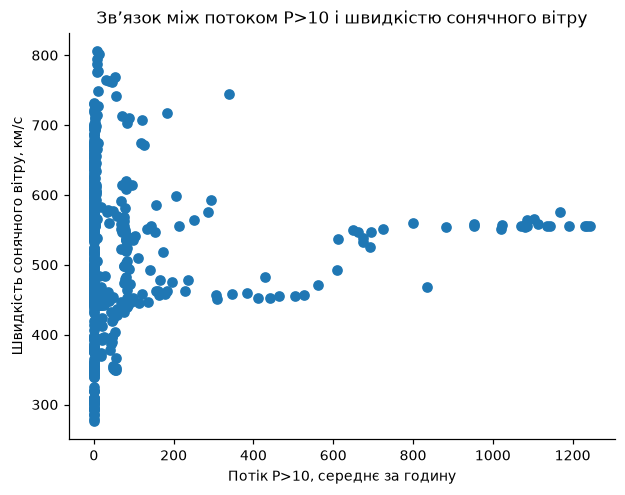

0.07096067649918364


In [ ]:
# ВАШ КОД
#P>10 Spped

couple = M[['P>10_mean', 'Speed']].dropna()
print(couple.head())

plt.scatter(couple['P>10_mean'], couple['Speed'])

plt.xlabel('Потік P>10, середнє за годину')
plt.ylabel('Швидкість сонячного вітру, км/с')
plt.title('Зв’язок між потоком P>10 і швидкістю сонячного вітру')
plt.show()

correlation = couple['P>10_mean'].corr(couple['Speed'])

print(correlation)



**Висновок:** По діагрмі розсіювання не утворюють чіткої тенденції, Також кореляційне значення між середнім погодинним потоком P>10 та швидкістю сонячного вітру становить приблизно 0,071, що близьке до нуля.Тому вираженого звязку між ними не спостерігається.

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

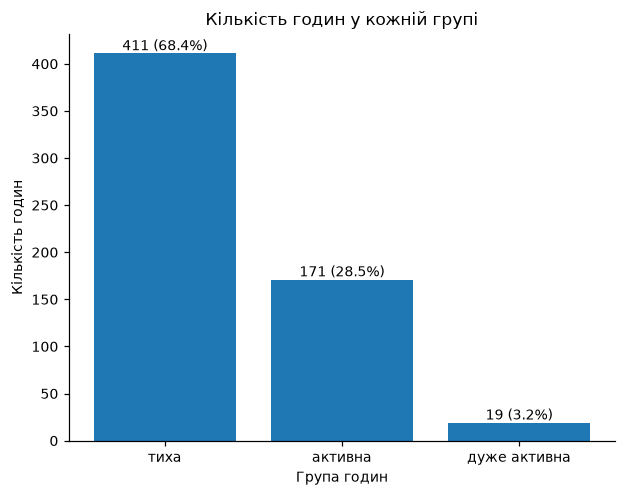

601
група
тиха            68.386023
активна         28.452579
дуже активна     3.161398
Name: count, dtype: float64


In [190]:
# ВАШ КОД

counts = M['група'].value_counts()

total = counts.sum()
percent = counts / total * 100

bars = plt.bar(counts.index, counts.values)

for bar, count, p in zip(bars, counts.values, percent.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{count} ({p:.1f}%)',
        ha='center',
        va='bottom'
    )

plt.xlabel('Група годин')
plt.ylabel('Кількість годин')
plt.title('Кількість годин у кожній групі')
plt.show()

print(total)
print(percent)


**Висновок:** Більшість годин належить до групи «тиха» — 411 годин (68,4%). «Активних» годин було 171 (28,5%), а «дуже активних» — лише 19 (3,2%). Отже, протягом досліджуваного періоду переважали години з низькою активністю потоку P>10, а дуже висока активність спостерігалася рідко.

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

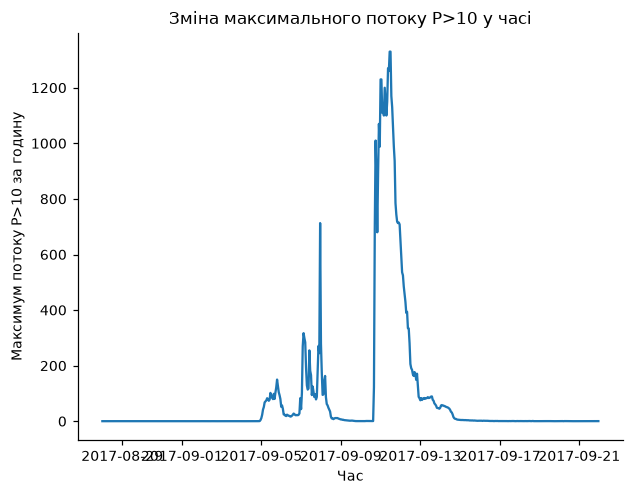

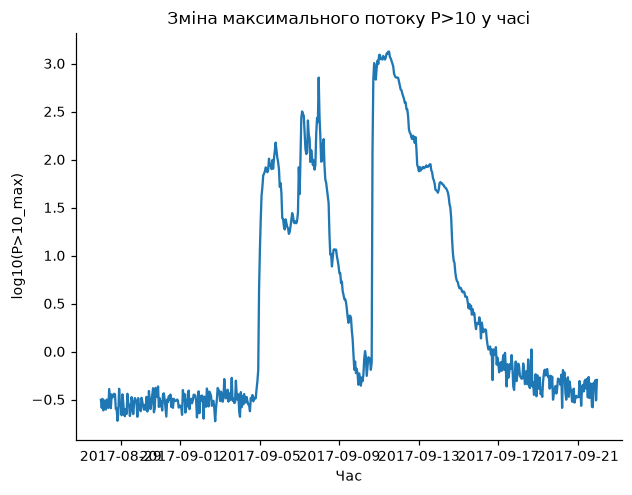

In [192]:
# ВАШ КОД
plt.plot(M['ts'], M['P>10_max'])

plt.xlabel('Час')
plt.ylabel('Максимум потоку P>10 за годину')
plt.title('Зміна максимального потоку P>10 у часі')
plt.show()


potik_log = np.log10(M['P>10_max'][M['P>10_max'] > 0])

plt.plot(M.loc[M['P>10_max'] > 0, 'ts'], potik_log)

plt.xlabel('Час')
plt.ylabel('log10(P>10_max)')
plt.title('Зміна максимального потоку P>10 у часі')
plt.show()

**Висновок:** Максимальний погодинний потік P>10 протягом більшої частини періоду мав відносно низькі значення. Приблизно з 5 вересня спостерігається різке зростання потоку з кількома піками, а найбільший період підвищеної активності припадає приблизно на 10–13 вересня. Після цього значення поступово зменшуються. Логарифмічне перетворення дозволило краще побачити зміни потоку при малих значеннях, які на звичайному графіку майже не помітні.

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

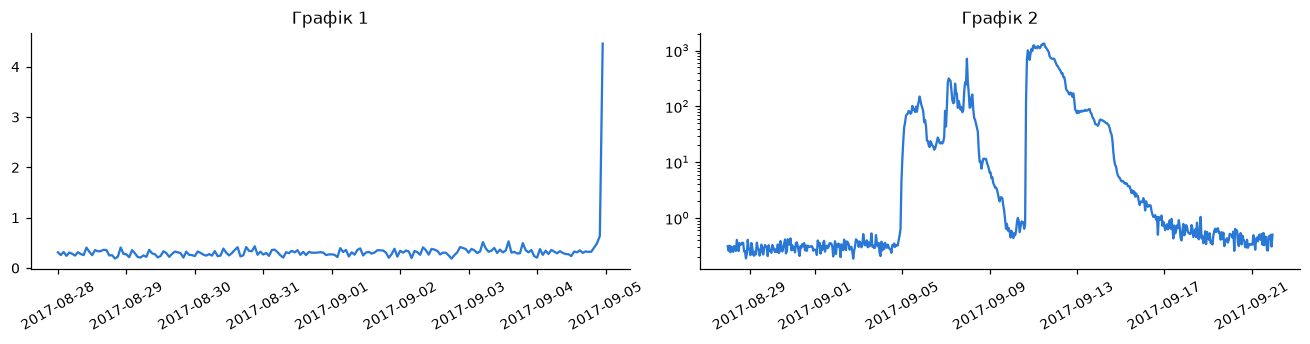

In [194]:
СТОВПЕЦЬ = 'P>10_max'   # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно['P>10_max'], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M['P>10_max'], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка: Я думаю, що вона побачить сатбільно рівномірно низький потік,але з початком вереня він дуже різко збільшився.
2. Висновок з другого графіка: Побачивши другий графік, людина може змінити свою думку ,а точніше бачення загальної картини графіка.Потік два рази різки збільшувався з приходом вересня.Найбільш активна була 10-11 вересня.
3. Дві відмінності між ними: Ну по перше у них різний часовий проміжок.Другий графік дає нам побачити ширшу картину осільки довший часовий проміжок.А також різна шкала Y.Через логарифмічну шкалу на другому графіку краще видно деталі.


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

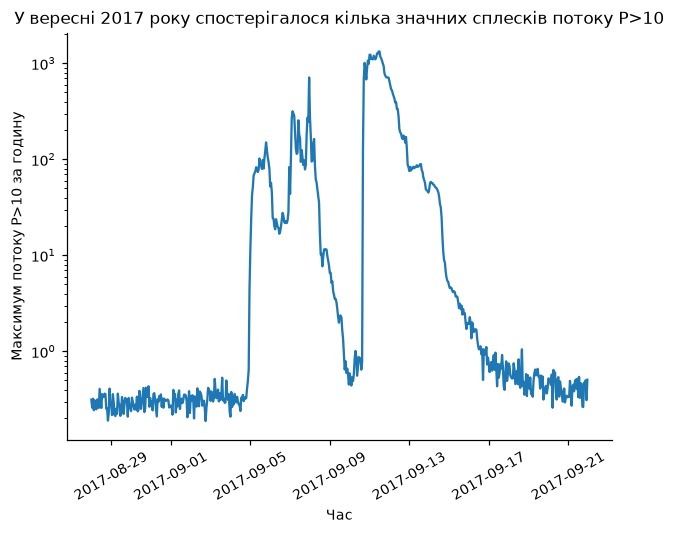

In [206]:
# ВАШ КОД

plt.plot(M['ts'], M['P>10_max'])

plt.yscale('log')

plt.xlabel('Час')
plt.ylabel('Максимум потоку P>10 за годину')
plt.title('У вересні 2017 року спостерігалося кілька значних сплесків потоку P>10')

plt.xticks(rotation=30)
plt.show()

**Відповідь 6.2:** *(чому ви побудували графік саме так)* Я обрала графік за весь період спостережень, щоб не приховувати частину даних, та використала логарифмічну шкалу, оскільки значення потоку P>10 дуже сильно відрізняються за величиною. Такий вигляд дозволяє одночасно побачити низькі значення потоку та значні сплески і краще передає загальну картину його зміни в часі.

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:** 
Між середнім погодинним потоком P>10 і швидкістю сонячного вітру практично немає лінійного зв’язку.Коефіцієнт кореляції становить приблизно 0,071, тобто близький до нуля. Це
видно на графіку 3 - діаграмі розсіювання, а також із розрахованого коефіцієнта кореляції.

**Спостереження 2:**
У групі «дуже активна» більшість значень швидкості сонячного вітру зосереджена приблизно біля 550 км/с, але присутні окремі викиди, зокрема значення близько 380 та 470 км/с. Це видно на графіку 2.

**Спостереження 3:**
Більшість годин належить до групи «тиха» — 411 годин (68,4%), активних було 171 (28,5%), а дуже активних — лише 19 (3,2%). Це видно на графіку 4


### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [207]:
# ВАШ КОД
#Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?
max_seria = 0
potochna_seria = 0

for grupa in M['група']:
    if grupa == 'активна':
        potochna_seria += 1
        max_seria = max(max_seria, potochna_seria)
    else:
        potochna_seria = 0

print("Найдовша серія активних годин:", max_seria)

Найдовша серія активних годин: 87


**Відповідь 7.2:** Найдовша серія активних годин тривала - 87 годин підряд.Для цього я перевірила групу кожної години та рахувала кількість з активної групи до їхнього завершення.

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [212]:
ІНСТРУМЕНТИ_ШІ = 'ChatGPT'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'синтаксис',
    'етап 3, паспорт даних і дивні значення':     'синтаксис',
    'етап 4, об’єднання таблиць':                 'синтаксис',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'ні',
    'етапи 6–7, порівняння графіків і спостереження': 'ні',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = 'Навчилася будувати різні види графіків, правильно відображати на них дані, змінювати масштаб, підписувати осі та аналізувати отримані результати.'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [213]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Андрусишин Соломія Володимирівна
інструменти:                                   ChatGPT
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    синтаксис
етап 3, паспорт даних і дивні значення:        синтаксис
етап 4, об’єднання таблиць:                    синтаксис
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                ні
етапи 6–7, порівняння графіків і спостереження: ні
------------------------------------------------------------------------------
перевірено автором:
Навчилася будувати різні види графіків, правильно відображати на них дані, змінювати масштаб, підписувати осі та аналізувати отримані результати.
Автор підтверджує, що може пояснити кожен рядок коду під час захисту.


---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [214]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (601, 28)


In [215]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
